<a href="https://colab.research.google.com/github/piercegregory-spec/python-exercises/blob/main/Mandelbrot_Julia_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install numba and ipympl before the accelerated cells
%pip install -q ipympl numba


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 88.9 MB/s eta 0:00:00


In [2]:
# The engine — single source of truth
# numba kernel if available, vectorised numpy otherwise.
# The explorer, the box magnifier, and escape_time all call _engine.

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    from numba import njit, prange

    # Escape-time counts; +inf = did not escape (interior, or not yet).
    # Mandelbrot: main cardioid + period-2 disk filled in analytically.
    # Julia: tight escape radius R = (1 + sqrt(1 + 4|c|))/2.
    # Cycle detection: a near-return is only believed after one full lap
    # returns again AND the cycle multiplier |(f^p)'|^2 < 1.  Attracting
    # cycles are interior; orbits shadowing a repelling cycle are not.
    @njit(parallel=True, fastmath=True)
    def _engine(re, im, max_iter, cre, cim, julia):
        out = np.empty((im.size, re.size))
        if julia:
            cabs = np.hypot(cre, cim)
            R = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * cabs))
            bail = 16.0 if R < 4.0 else R * R
        else:
            bail = 16.0
        for j in prange(im.size):
            yi = im[j]
            y2 = yi * yi
            for i in range(re.size):
                xi = re[i]
                if julia:
                    zr, zi, cr, ci = xi, yi, cre, cim
                else:
                    zr, zi, cr, ci = 0.0, 0.0, xi, yi
                    xq = xi - 0.25
                    q = xq * xq + y2
                    # main cardioid, or the period-2 disk
                    if q * (q + xq) <= 0.25 * y2 or (xi + 1.0) * (xi + 1.0) + y2 <= 0.0625:
                        out[j, i] = np.inf
                        continue
                z2 = zr * zr + zi * zi
                if z2 > bail:                                  # already outside
                    out[j, i] = 1.0 - np.log2(np.log2(z2) * 0.5)
                    continue
                mu = np.inf
                zr0, zi0 = zr, zi    # reference point, refreshed every 20 steps
                vr = vi = 0.0        # candidate periodic point while verifying
                lag = 0              # steps since the reference
                left = 0             # verification countdown
                wm2 = 1.0            # |(f^p)'|^2, accumulated over the lap
                for k in range(1, max_iter + 1):
                    zr, zi = zr*zr - zi*zi + cr, 2.0*zr*zi + ci
                    z2 = zr*zr + zi*zi
                    if not z2 <= bail:                          # escaped (NaN-safe)
                        if np.isfinite(z2) and z2 > 1.0:
                            mu = k - np.log2(np.log2(z2) * 0.5) + 1.0
                        else:
                            mu = float(k)
                        break
                    if left > 0:                                # verification lap
                        wm2 *= 4.0 * z2                         # *= |2z|^2 this step
                        left -= 1
                        if left == 0:
                            dr, di = zr - vr, zi - vi
                            if dr*dr + di*di < 1e-20 and wm2 < 1.0:
                                break                           # attracting -> interior
                            zr0, zi0, lag = zr, zi, 0           # false alarm; resume
                    else:                                       # watching for a return
                        lag += 1
                        dr, di = zr - zr0, zi - zi0
                        if dr*dr + di*di < 1e-20:
                            vr, vi = zr, zi                     # candidate; verify it
                            left, wm2 = lag, 1.0
                        elif lag == 20:
                            zr0, zi0, lag = zr, zi, 0
                out[j, i] = mu
        return out
    _ACCEL = "numba"

except ImportError:
    # Vectorised fallback.  Deliberately no cycle detection: interior orbits
    # simply run to max_iter and return +inf, which colours black exactly like
    # the kernel's verified early exit — same image, only the speed differs.
    def _engine(re, im, max_iter, cre, cim, julia):
        grid = re[None, :] + 1j * im[:, None]
        if julia:
            z = grid
            c = np.full_like(grid, complex(cre, cim))
            cabs = np.hypot(cre, cim)
            R = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * cabs))
            bail = 16.0 if R < 4.0 else float(R * R)
            main = np.zeros(grid.shape, dtype=bool)
        else:
            z = np.zeros_like(grid)
            c = grid
            x, y = c.real, c.imag
            q = (x - 0.25)**2 + y**2
            main = (q * (q + (x - 0.25)) <= 0.25 * y**2) | ((x + 1.0)**2 + y**2 <= 0.0625)
            bail = 16.0
        mu = np.full(z.shape, np.inf)
        alive = ~main
        z2 = z.real**2 + z.imag**2
        pre = alive & (z2 > bail)          # already beyond the escape radius
        if pre.any():
            mu[pre] = 1.0 - np.log2(np.log2(z2[pre]) / 2.0)
            alive[pre] = False
        for k in range(1, max_iter + 1):
            if not alive.any():
                break
            za = z[alive] * z[alive] + c[alive]
            z[alive] = za
            a2 = za.real**2 + za.imag**2
            esc = ~np.isfinite(a2) | (a2 > bail)
            if esc.any():
                idx = np.flatnonzero(alive)[esc]
                a2e = a2[esc]
                ok = np.isfinite(a2e) & (a2e > 1.0)
                vals = np.full(idx.shape, float(k))
                if ok.any():
                    vals[ok] = k + 1.0 - np.log2(np.log2(a2e[ok]) / 2.0)
                mu.ravel()[idx] = vals
                alive.ravel()[idx] = False
        return mu
    _ACCEL = "numpy (pip install numba for ~20–40× speedup)"

def escape_time(center, span, pixels=800, max_iter=300, julia_c=None):
    """Thin wrapper so the static cells read nicely.
       julia_c=None -> Mandelbrot (z starts at 0, c roams the screen)
       julia_c=c    -> Julia      (z roams the screen, c is pinned)
       Returns smooth escape counts; +inf = stays bounded (renders black)."""
    re = np.linspace(center.real - span/2, center.real + span/2, pixels)
    im = np.linspace(center.imag - span/2, center.imag + span/2, pixels)
    jc = julia_c if julia_c is not None else 0j
    return _engine(re, im, max_iter, jc.real, jc.imag, julia_c is not None)

def color_limits(finite):
    """Color range from the central 99% of escaped pixels, so one speck
    does not stretch the scale."""
    if getattr(finite, "size", 0) == 0:
        return None
    lo, hi = np.percentile(np.asanyarray(finite, dtype=float), [0.5, 99.5])
    lo, hi = float(lo), float(hi)
    if not hi > lo:
        hi = lo + 1.0
    return lo, hi

def show(mu, center, span, cmap="magma", title=""):
    cm = mpl.colormaps[cmap].copy()
    cm.set_bad("black")
    data = np.ma.masked_invalid(mu)
    plt.figure(figsize=(8, 8))
    im = plt.imshow(data, cmap=cm,
                    extent=(center.real - span/2, center.real + span/2,
                            center.imag - span/2, center.imag + span/2),
                    origin="lower", interpolation="bilinear")
    lim = color_limits(data.compressed())
    if lim:
        im.set_clim(*lim)
    plt.title(title); plt.axis("off"); plt.show()


1985 mode, the Dewdney homage (ASCII, like the dot-matrix printouts readers mailed in — except his took all night, and this takes a second)

In [3]:
# Cell 2
# 1985 mode, Dewdney homage
def ascii_mandelbrot(cols=80, rows=30, max_iter=60):
    shades = " .:-=+*#%@"
    lines = []
    for r in range(rows):
        y = 1.15 - 2.3 * r / (rows - 1)
        row = ""
        for i in range(cols):
            x = -2.1 + 2.8 * i / (cols - 1)
            zr, zi, cr, ci = 0.0, 0.0, x, y
            k = 0
            while k < max_iter and zr*zr + zi*zi <= 4.0:
                zr, zi = zr*zr - zi*zi + cr, 2.0*zr*zi + ci
                k += 1
            row += shades[k * 9 // max_iter]
        lines.append(row)
    return "\n".join(lines)

print(ascii_mandelbrot())

                                                                                
                                                      ..                        
                                                     .....:.                    
                                                    ...:*....                   
                                                  ..::=@@%::..                  
                                                ....:@@@@@@-...                 
                                         .=.:....:..::@@@@-:...-.......         
                                         ..:@@+:@@@@@@@@@@@@@@@@-..@:::.        
                                       .....:@@@@@@@@@@@@@@@@@@@@@@@@@.         
                       ..           ....-@@@@@@@@@@@@@@@@@@@@@@@@@@@@:..        
                       .......-........==@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@#.       
                      ....:+---@::.....%@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@-..       
                    .....:-@

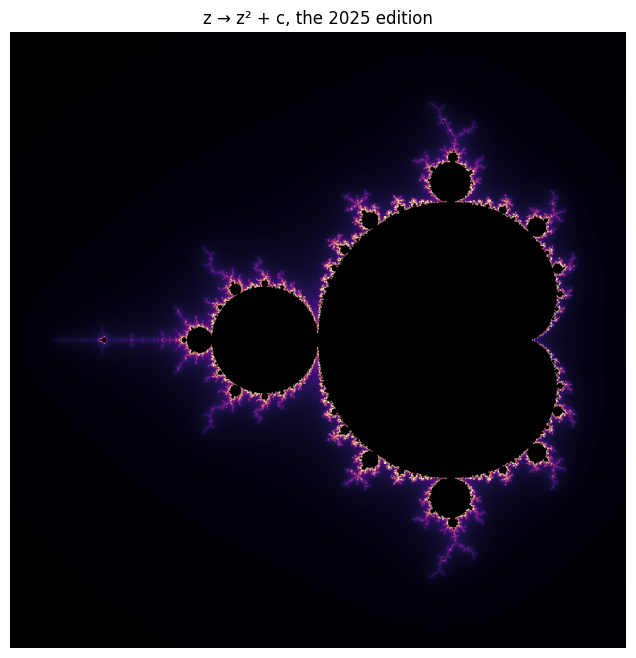

In [4]:
# Cell 3
# The full set in color

mu = escape_time(-0.75 + 0j, span=2.9, pixels=800, max_iter=250)
show(mu, -0.75 + 0j, 2.9, cmap="magma", title="z → z² + c, the 2025 edition")

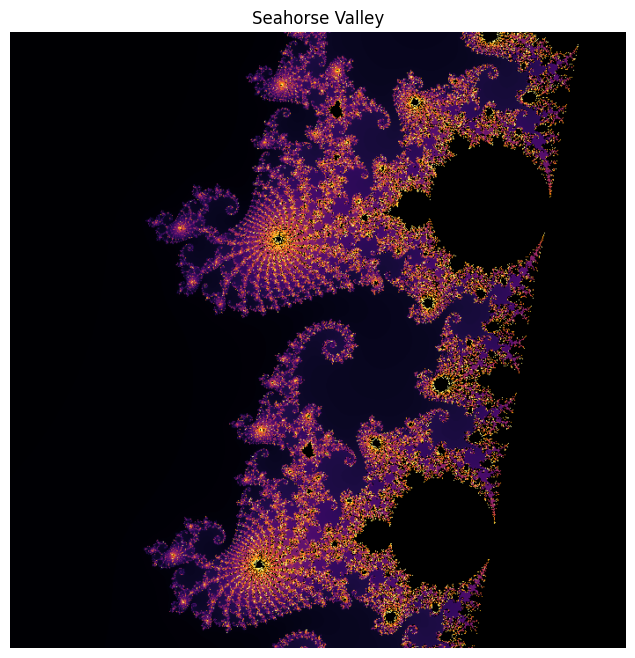

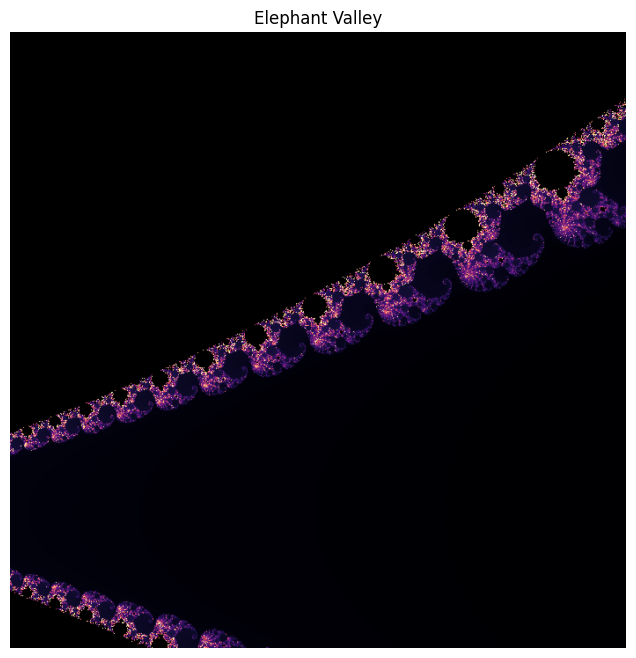

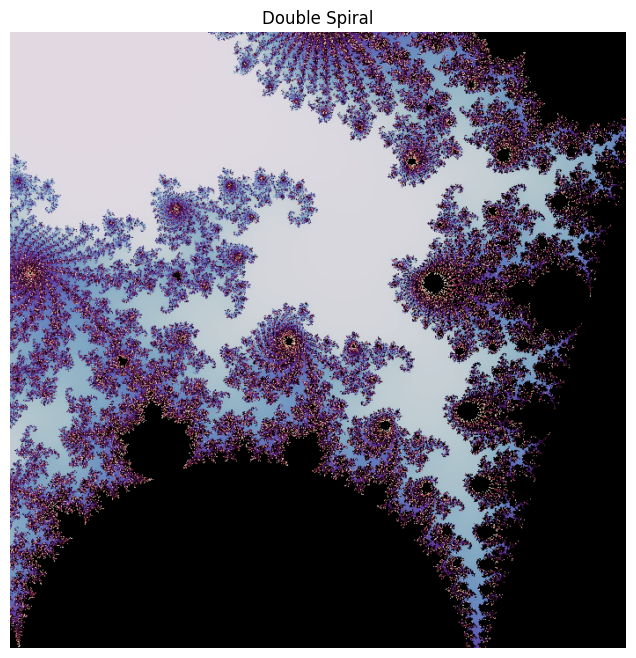

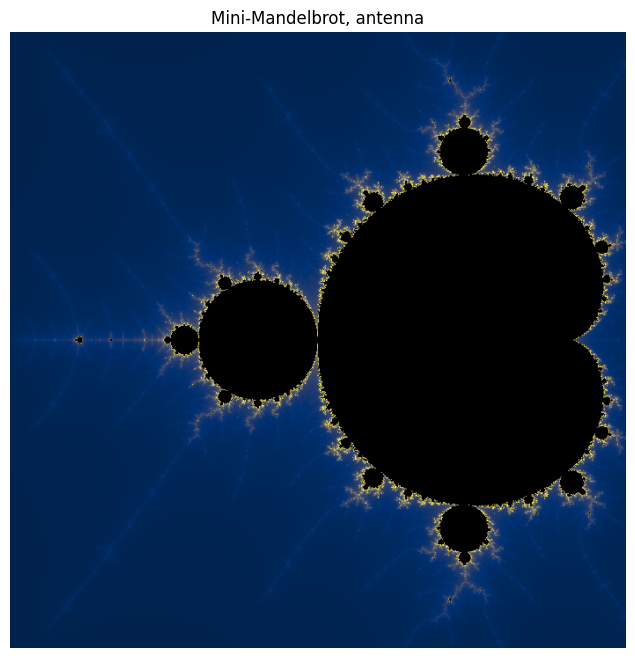

In [5]:
# Cell4
# Scenic Overlooks
LANDMARKS = {
    "Seahorse Valley":          (-0.7455 + 0.1127j, 0.015, "inferno"),
    "Elephant Valley":          ( 0.2760 + 0.0070j, 0.025, "magma"),
    "Double Spiral":            (-0.7269 + 0.1889j, 0.010, "twilight"),
    "Mini-Mandelbrot, antenna": (-1.7685 + 0.0j,    0.045, "cividis"),
}
for name, (c0, sp, cm) in LANDMARKS.items():
    show(escape_time(c0, sp, pixels=700, max_iter=600), c0, sp, cmap=cm, title=name)

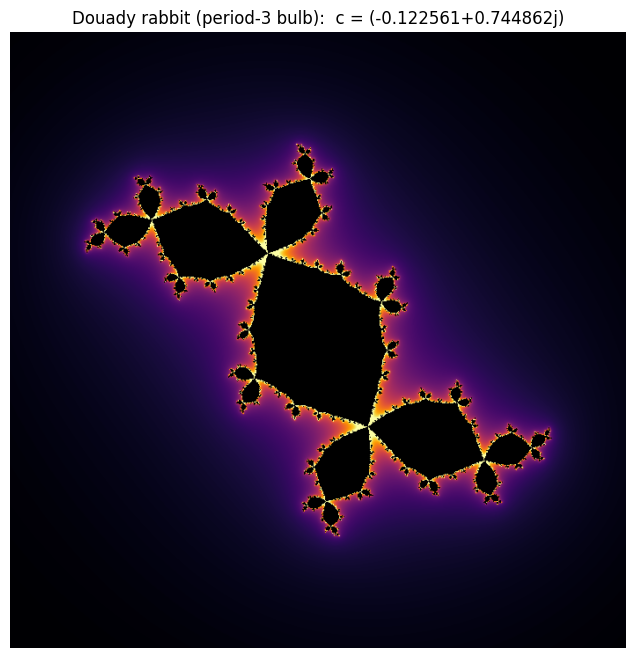

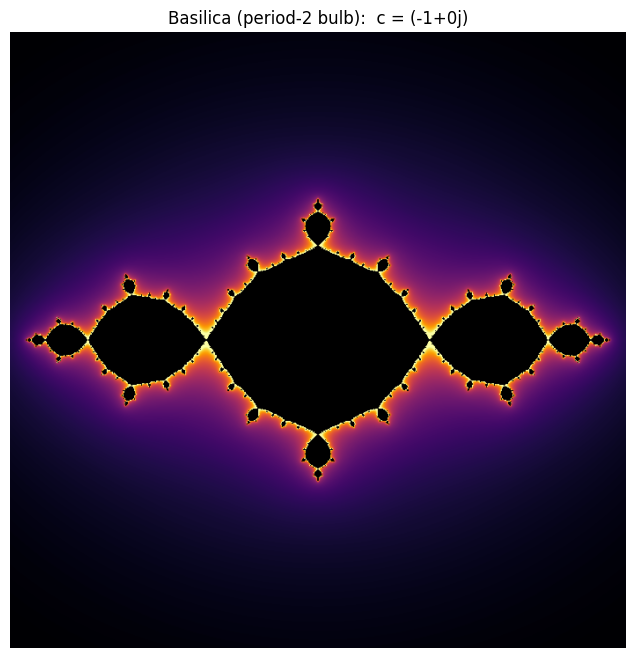

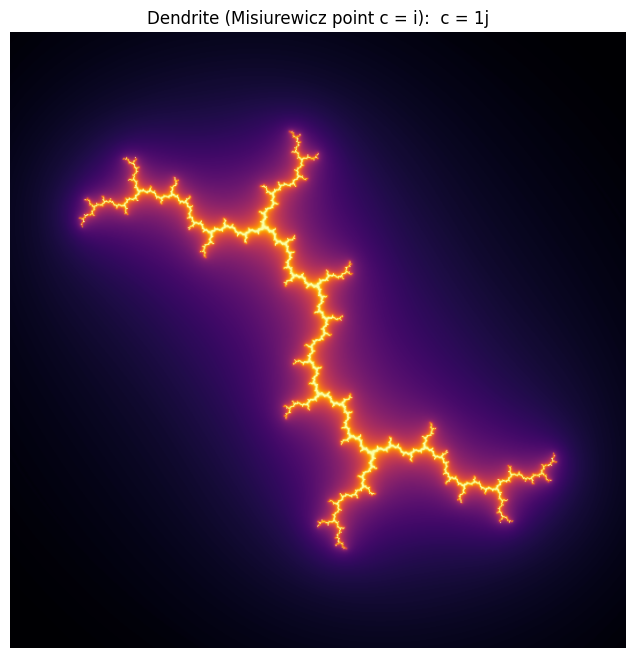

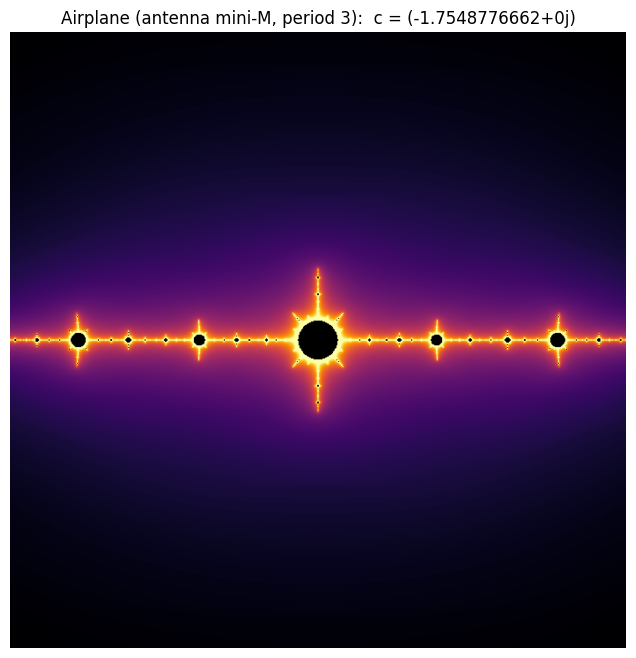

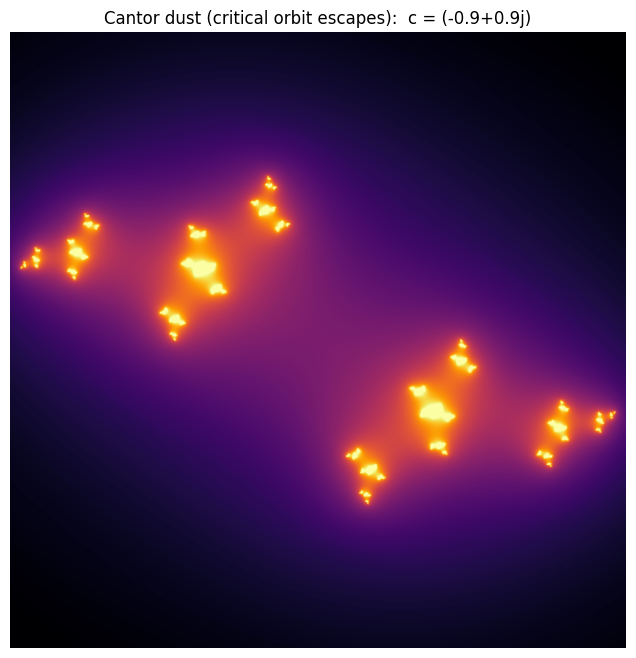

In [6]:
#  Cell 5 — the Douady dictionary (connected when c is in M,
#  Cantor dust when it isn't — the dichotomy now in pictures)

JULIAS = {
    "Douady rabbit (period-3 bulb)":        -0.122561 + 0.744862j,
    "Basilica (period-2 bulb)":             -1.0 + 0j,
    "Dendrite (Misiurewicz point c = i)":   1j,
    "Airplane (antenna mini-M, period 3)":  -1.7548776662 + 0j,
    "Cantor dust (critical orbit escapes)": -0.9 + 0.9j,
}
for name, c in JULIAS.items():
    show(escape_time(0j, 3.4, pixels=700, max_iter=400, julia_c=c),
         0j, 3.4, cmap="inferno", title=f"{name}:  c = {c}")

In [7]:
# Cell 6--Interactive Explorer

import ipywidgets as widgets

def explore(re_center=-0.75, im_center=0.0, halvings=0, max_iter=400,
            cmap="magma", julia_c=""):
    span = 3.0 / 2**halvings          # 40 halvings ≈ 20 ulps per pixel in float64
    jc = None
    if julia_c.strip():
        try:
            jc = complex(julia_c)
        except ValueError:
            return print("Couldn't parse c — use a form like -0.75+0.1j")
    center = complex(re_center, im_center)
    show(escape_time(center, span, pixels=600, max_iter=max_iter, julia_c=jc),
         center, span, cmap=cmap)

widgets.interact_manual(
    explore,
    re_center=widgets.FloatText(-0.75, description="Re center"),
    im_center=widgets.FloatText(0.0, description="Im center"),
    halvings=widgets.IntSlider(0, 0, 40, description="zoom (halvings)"),
    max_iter=widgets.IntSlider(400, 100, 3000, 100, description="max iter"),
    cmap=["magma", "inferno", "twilight", "twilight_shifted", "viridis", "cividis"],
    julia_c=widgets.Text("", placeholder="Julia c, e.g. -0.123+0.745j (blank = Mandelbrot)"),
);


interactive(children=(FloatText(value=-0.75, description='Re center'), FloatText(value=0.0, description='Im ce…

CPU times: user 237 ms, sys: 3.74 ms, total: 241 ms
Wall time: 131 ms


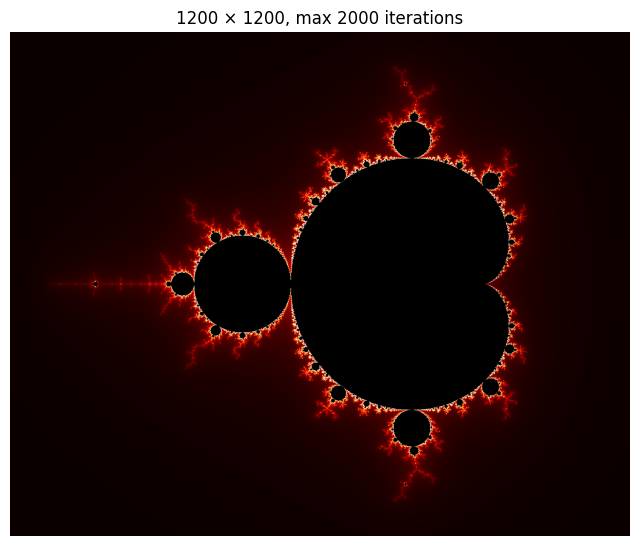

In [8]:
# Moore's law payoff

re = np.linspace(-2.2, 1.0, 1200)
im = np.linspace(-1.3, 1.3, 1200)
%time img = _engine(re, im, 2000, 0.0, 0.0, False)
cm = mpl.colormaps["hot"].copy()
cm.set_bad("black")
plt.figure(figsize=(8, 8))
shown = plt.imshow(np.ma.masked_invalid(img), cmap=cm, origin="lower",
                   extent=(re[0], re[-1], im[0], im[-1]))
lim = color_limits(np.ma.masked_invalid(img).compressed())
if lim:
    shown.set_clim(*lim)
plt.axis("off"); plt.title("1200 × 1200, max 2000 iterations"); plt.show()


In [10]:
# Cell 9--Explorer

%matplotlib widget

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

LANDMARKS = {
    "Seahorse Valley":   (-0.7455 + 0.1127j, 0.015),
    "Elephant Valley":   ( 0.2760 + 0.0072j, 0.020),
    "Triple spiral":     (-0.0880 + 0.6540j, 0.030),
    "Double spiral":     (-0.7269 + 0.1889j, 0.010),
    "Mini-M on antenna": (-1.7685 + 0.0000j, 0.045),
    "Misiurewicz c = i": ( 0.0000 + 1.0000j, 0.040),
}

class FractalExplorer:
    """Click-to-zoom Mandelbrot/Julia explorer for ipympl notebooks.

    left-click      zoom in 2× toward the cursor
    right-click     zoom out 2×   (shift-click works too)
    scroll wheel    zoom at cursor
    middle-click    recenter without zooming
    ctrl-click      point-and-shoot: jump to the Julia set for that c
    """

    def __init__(self, pixels=600, cmap="magma"):
        self.pixels, self.cmap = pixels, cmap
        self.home = (-0.75 + 0j, 2.9)
        self.center, self.span = self.home
        self.zoom_ref = self.home[1]             # magnification is vs this span
        self.min_span = self.home[1] / 2**40     # float64: ~20 ulps per pixel
        self._axes_hold = False                  # True while a click owns the view
        self._limits = None                      # last limits this class applied
        self.base_iter, self.max_iter = 300, 300
        self.julia_c = None
        self.m_view = None                    # saved Mandelbrot view while in Julia mode
        self._syncing = False
        self._build_ui()
        self.render()

    # ---------------- UI ----------------
    def _build_ui(self):
        self.out = widgets.Output()
        with self.out:
            self.fig, self.ax = plt.subplots(figsize=(6.6, 6.6))
        self.ax.set_aspect("equal")
        self.ax.set_xticks([]); self.ax.set_yticks([])
        self.imshow = None

        self.status = widgets.HTML()
        self.landmarks = widgets.Dropdown(
            options=[("— jump to —", None)] + [(k, k) for k in LANDMARKS],
            value=None, layout=widgets.Layout(width="180px"))
        self.landmarks.observe(self._on_landmark, "value")
        self.cmap_dd = widgets.Dropdown(
            options=["magma", "inferno", "twilight_shifted", "viridis", "cividis", "hot"],
            value=self.cmap, layout=widgets.Layout(width="150px"))
        self.cmap_dd.observe(self._on_cmap, "value")

        self.btn_home = widgets.Button(description="⌂ home")
        self.btn_home.on_click(self._on_home)
        self.btn_back = widgets.Button(description="← Mandelbrot", disabled=True)
        self.btn_back.on_click(self._on_back)
        self.btn_save = widgets.Button(description="save PNG")
        self.btn_save.on_click(self._on_save)

        self.auto_iter = widgets.Checkbox(value=True, description="auto iterations", indent=False)
        self.auto_iter.observe(self._on_auto, "value")
        self.iter_slider = widgets.IntSlider(value=300, min=100, max=5000, step=50,
                                             description="max_iter", disabled=True,
                                             layout=widgets.Layout(width="380px"))
        self.iter_slider.observe(self._on_iter, "value")

        hint = widgets.HTML("<small><b>click</b> zoom in · <b>right/shift-click</b> out · "
                            "<b>scroll</b> zoom · <b>middle-click</b> recenter · "
                            "<b>ctrl-click</b> point-and-shoot Julia</small>")
        display(widgets.VBox([hint, self.out,
                              widgets.HBox([self.landmarks, self.cmap_dd, self.btn_home,
                                            self.btn_back, self.btn_save]),
                              widgets.HBox([self.auto_iter, self.iter_slider]),
                              self.status]))

        self.fig.canvas.mpl_connect("button_press_event", self._on_click)
        self.fig.canvas.mpl_connect("scroll_event", self._on_scroll)

    # ---------------- events ----------------
    def _toolbar_moved(self):
        if self._limits is None:
            return False
        (x0, x1), (y0, y1) = self.ax.get_xlim(), self.ax.get_ylim()
        lx0, lx1, ly0, ly1 = self._limits
        tol = 1e-8 * max(abs(lx1 - lx0), 1e-30)
        return (abs(x0 - lx0) > tol or abs(x1 - lx1) > tol
                or abs(y0 - ly0) > tol or abs(y1 - ly1) > tol)

    def _sync_from_axes(self):
        """Adopt a pan or zoom made with the toolbar buttons."""
        (x0, x1), (y0, y1) = self.ax.get_xlim(), self.ax.get_ylim()
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        span = (x1 - x0 + y1 - y0) / 2
        if not np.isfinite(span) or span <= 0:
            return
        tol = 1e-12 * max(self.span, 1e-30)
        moved = abs(cx - self.center.real) > tol or abs(cy - self.center.imag) > tol
        resized = abs(span - self.span) > tol
        if moved or resized:
            self.center = complex(cx, cy)
            self.span = max(span, self.min_span)

    def _on_click(self, ev):
        if ev.inaxes is not self.ax or ev.xdata is None:
            return
        self._sync_from_axes()
        key = ev.key or ""
        if "ctrl" in key or "control" in key:
            if self.julia_c is None:                       # point-and-shoot
                self.m_view = (self.center, self.span)
                self._axes_hold = True
                self.julia_c = complex(ev.xdata, ev.ydata)
                self.center = 0j
                self.span = max(4.0, 2.5 * abs(self.julia_c))
                self.zoom_ref = self.span          # Julia zoom starts at 1×
                self.render()
            return
        if "shift" in key or ev.button == 3:
            self.zoom_at(ev.xdata, ev.ydata, 2.0)
        elif ev.button == 1:
            self.zoom_at(ev.xdata, ev.ydata, 0.5)
        elif ev.button == 2:
            self._axes_hold = True
            self.center = complex(ev.xdata, ev.ydata)
            self.render()

    def _on_scroll(self, ev):
        if ev.inaxes is not self.ax or ev.xdata is None:
            return
        self._sync_from_axes()
        self.zoom_at(ev.xdata, ev.ydata, 0.8 if ev.button == "up" else 1.25)

    def _on_landmark(self, change):
        if not change["new"]:
            return
        self._axes_hold = True
        self.center, self.span = LANDMARKS[change["new"]]
        self.julia_c = None
        self.zoom_ref = self.home[1]
        if self.auto_iter.value:
            self.max_iter = self._auto_iter()
        self.render()
        self.landmarks.value = None

    def _on_cmap(self, change):
        self.cmap = change["new"]
        if self.imshow is not None:
            self.imshow.set_cmap(self._cmap())
            self.fig.canvas.draw_idle()

    def _on_home(self, _):
        self._axes_hold = True
        self.center, self.span, self.julia_c = self.home[0], self.home[1], None
        self.zoom_ref = self.home[1]
        if self.auto_iter.value:
            self.max_iter = self.base_iter
        self.render()

    def _on_back(self, _):
        self._axes_hold = True
        self.julia_c = None
        if self.m_view:
            self.center, self.span = self.m_view
        self.zoom_ref = self.home[1]
        if self.auto_iter.value:
            self.max_iter = self._auto_iter()
        self.render()

    def _on_save(self, _):
        from datetime import datetime
        fname = datetime.now().strftime("fractal_%Y%m%d_%H%M%S.png")
        self.fig.savefig(fname, dpi=220, bbox_inches="tight")
        self.status.value = f"<small>saved <code>{fname}</code></small><br>" + self.status.value

    def _on_auto(self, change):
        self.iter_slider.disabled = change["new"]
        if change["new"]:
            self.max_iter = self._auto_iter()
            self.render()

    def _on_iter(self, change):
        if self._syncing:
            return
        self.max_iter = change["new"]
        self.render()

    # ---------------- math / rendering ----------------
    def _auto_iter(self):
        depth = np.log2(self.home[1] / self.span)          # zoom halvings since start
        return int(np.clip(self.base_iter + 60 * depth, self.base_iter, 5000))

    def zoom_at(self, x, y, factor):
        pt = complex(x, y)
        if factor < 1.0 and self.span * factor < self.min_span:
            if self.span <= self.min_span * (1.0 + 1e-9):
                return                                 # float64 zoom limit
            factor = self.min_span / self.span
        self._axes_hold = True
        self.center = pt + (self.center - pt) * factor     # keep the cursor point fixed
        self.span *= factor
        if self.auto_iter.value:
            self.max_iter = self._auto_iter()
        self.render()

    def _cmap(self):
        cm = mpl.colormaps[self.cmap].copy()
        cm.set_bad("black")
        return cm

    def render(self):
        if self.imshow is not None and not self._axes_hold and self._toolbar_moved():
            self._sync_from_axes()
        self._axes_hold = False
        t0 = time.time()
        re = np.linspace(self.center.real - self.span/2, self.center.real + self.span/2, self.pixels)
        im = np.linspace(self.center.imag - self.span/2, self.center.imag + self.span/2, self.pixels)
        jc = self.julia_c if self.julia_c is not None else 0j
        mu = _engine(re, im, self.max_iter, jc.real, jc.imag, self.julia_c is not None)
        data = np.ma.masked_invalid(mu)                    # interior (never escapes) -> black

        if self.imshow is None:
            self.imshow = self.ax.imshow(data, cmap=self._cmap(),
                                         origin="lower", interpolation="bilinear",
                                         extent=(re[0], re[-1], im[0], im[-1]))
        else:
            self.imshow.set_data(data)
            self.imshow.set_extent((re[0], re[-1], im[0], im[-1]))
        lim = color_limits(data.compressed())
        if lim:
            self.imshow.set_clim(*lim)
        self.ax.set_xlim(re[0], re[-1]); self.ax.set_ylim(im[0], im[-1])
        self._limits = (re[0], re[-1], im[0], im[-1])
        self.btn_back.disabled = self.julia_c is None

        self._syncing = True
        self.iter_slider.value = int(min(self.max_iter, 5000))
        self._syncing = False

        zoom = self.zoom_ref / self.span
        mode = (f"Julia, c = {self.julia_c.real:+.10g}{self.julia_c.imag:+.10g}i"
                if self.julia_c is not None else "Mandelbrot")
        warn = " &nbsp;⚠ float64 zoom limit" if self.span <= self.min_span * 1.01 else ""
        self.status.value = (f"<small><b>{mode}</b> · center "
                             f"{self.center.real:+.12g}{self.center.imag:+.12g}i · "
                             f"span {self.span:.3g} · zoom ×{zoom:,.0f} · "
                             f"max_iter {self.max_iter} · {time.time() - t0:.2f}s · "
                             f"engine: {_ACCEL}{warn}</small>")
        self.fig.canvas.draw_idle()

explorer = FractalExplorer()   # your 1985 machine, upgraded. Try FractalExplorer(pixels=400) if renders feel slow.


ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

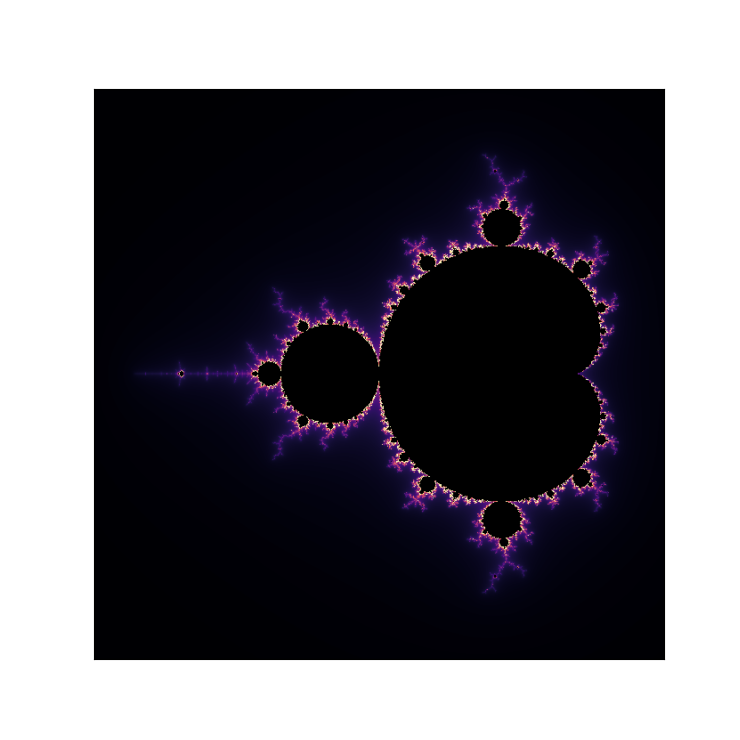

In [ ]:
# Draw a box, magnify what's inside

%matplotlib widget

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.widgets import RectangleSelector
import matplotlib.patheffects as pe
from IPython.display import display

class BoxMagnifier:
    """Drag a rectangle around a piece of the Mandelbrot set.

    The points inside the box are recomputed and become the new picture.
    Shift-drag forces a square. Right-click, or ←, steps back one box.
    """

    def __init__(self, pixels=640, cmap="magma"):
        self.long_pixels = pixels
        self.cmap_name = cmap
        # same window as the explorer's home view
        self.home = (-2.2, 0.7, -1.45, 1.45)          # x0, x1, y0, y1
        self.bounds = self.home
        self.history = []
        self.min_span = 2.9 / 2**40                    # float64: ~20 ulps per pixel
        self.base_iter = 300
        self.max_iter = self.base_iter
        self._build_ui()
        self.render()

    def _build_ui(self):
        self.out = widgets.Output()
        with self.out:
            self.fig, self.ax = plt.subplots(figsize=(7.2, 7.2))
        self.ax.set_aspect("equal", adjustable="box")
        self.ax.set_xticks([]); self.ax.set_yticks([])
        try:
            self.fig.canvas.toolbar_visible = False
        except Exception:
            pass
        self.imshow = None

        self.status = widgets.HTML()
        self.btn_back = widgets.Button(description="← back", disabled=True)
        self.btn_back.on_click(lambda _: self.back())
        self.btn_home = widgets.Button(description="⌂ home")
        self.btn_home.on_click(lambda _: self.home_view())
        hint = widgets.HTML(
            "<small><b>drag a box</b> to magnify the points inside · "
            "<b>shift-drag</b> square · <b>right-click</b> or ← back</small>")
        display(widgets.VBox([
            hint, self.out,
            widgets.HBox([self.btn_back, self.btn_home]),
            self.status]))

        # useblit stays off: a blitted rectangle is skipped by the widget
        # canvas, so the box never appears while you drag.
        self.selector = RectangleSelector(
            self.ax, self._on_select,
            useblit=False, button=[1],
            minspanx=8, minspany=8, spancoords="pixels",
            interactive=False,
            props=dict(facecolor=(1.0, 0.86, 0.1, 0.35),
                       edgecolor="#ffe14a", linewidth=2.8, fill=True,
                       zorder=5,
                       path_effects=[pe.Stroke(linewidth=6, foreground="black"),
                                     pe.Normal()]))
        self.fig.canvas.mpl_connect("button_press_event", self._on_click)
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)

    def _on_click(self, ev):
        if ev.button == 3 and ev.inaxes is self.ax:
            self.back()

    def _on_key(self, ev):
        if ev.key == "left":
            self.back()

    def _on_select(self, eclick, erelease):
        if eclick.xdata is None or erelease.xdata is None:
            return
        if eclick.ydata is None or erelease.ydata is None:
            return
        x0, x1 = sorted((float(eclick.xdata), float(erelease.xdata)))
        y0, y1 = sorted((float(eclick.ydata), float(erelease.ydata)))
        # keep the box on the picture that is actually showing
        xa, xb, ya, yb = self.bounds
        x0, x1 = max(x0, xa), min(x1, xb)
        y0, y1 = max(y0, ya), min(y1, yb)
        if x1 <= x0 or y1 <= y0:
            return
        if x1 - x0 < self.min_span or y1 - y0 < self.min_span:
            self.status.value = ("<small>⚠ that box is past the float64 zoom limit"
                                 " — release a larger one</small>")
            return
        self.history.append(self.bounds)
        self.bounds = (x0, x1, y0, y1)
        self.max_iter = self._auto_iter()
        self.render()

    def _auto_iter(self):
        hx = self.home[1] - self.home[0]
        short = min(self.bounds[1] - self.bounds[0], self.bounds[3] - self.bounds[2])
        depth = np.log2(hx / short)
        return int(np.clip(self.base_iter + 60 * depth, self.base_iter, 5000))

    def back(self):
        if not self.history:
            return
        self.bounds = self.history.pop()
        self.max_iter = self._auto_iter()
        self.render()

    def home_view(self):
        self.history.clear()
        self.bounds = self.home
        self.max_iter = self.base_iter
        self.render()

    def _shape(self, w, h):
        long = self.long_pixels
        if w >= h:
            nx = long
            ny = max(48, int(round(long * h / w)))
        else:
            ny = long
            nx = max(48, int(round(long * w / h)))
        return nx, ny

    def _cmap(self):
        cm = mpl.colormaps[self.cmap_name].copy()
        cm.set_bad("black")
        return cm

    def render(self):
        t0 = time.time()
        x0, x1, y0, y1 = self.bounds
        w, h = x1 - x0, y1 - y0
        nx, ny = self._shape(w, h)
        re = np.linspace(x0, x1, nx)
        im = np.linspace(y0, y1, ny)
        mu = _engine(re, im, self.max_iter, 0.0, 0.0, False)
        data = np.ma.masked_invalid(mu)

        if self.imshow is None:
            self.imshow = self.ax.imshow(
                data, cmap=self._cmap(), origin="lower", interpolation="bilinear",
                extent=(re[0], re[-1], im[0], im[-1]))
        else:
            self.imshow.set_data(data)
            self.imshow.set_extent((re[0], re[-1], im[0], im[-1]))
        lim = color_limits(data.compressed())
        if lim:
            self.imshow.set_clim(*lim)
        self.ax.set_xlim(re[0], re[-1])
        self.ax.set_ylim(im[0], im[-1])

        long, short = 7.4, max(2.2, 7.4 * min(w, h) / max(w, h))
        if w >= h:
            self.fig.set_size_inches(long, short, forward=True)
        else:
            self.fig.set_size_inches(short, long, forward=True)

        self.btn_back.disabled = not self.history
        zoom = ((self.home[1] - self.home[0]) * (self.home[3] - self.home[2])) / (w * h)
        warn = " &nbsp;⚠ float64 zoom limit" if min(w, h) <= self.min_span * 1.01 else ""
        self.status.value = (
            f"<small><b>Mandelbrot</b> · "
            f"[{x0:+.12g}, {x1:+.12g}] × [{y0:+.12g}, {y1:+.12g}] · "
            f"{nx}×{ny} · zoom ×{zoom:,.1f} · "
            f"max_iter {self.max_iter} · {time.time() - t0:.2f}s · "
            f"engine: {_ACCEL}{warn}</small>")
        self.fig.canvas.draw_idle()

if "_engine" not in globals():
    print("Run the engine cell above first — this one uses its engine.")
else:
    boxzoom = BoxMagnifier()   # BoxMagnifier(pixels=400) if a drag feels slow
